<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/project_nathan/nathan_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [2]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nathansawatzky","key":"703072937f56fc86b08c5c9e6f0bb134"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!pip install kagglehub

!pip install tensorflow==2.15.1 tf_keras==2.15.1 tensorflow-model-optimization==0.8.0


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.1


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.27G/1.27G [00:13<00:00, 101MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6


In [6]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
import tensorflow as tf

import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

print("Root:", path)
print("Level 1:", os.listdir(path))

for item in os.listdir(path):
    sub = os.path.join(path, item)
    if os.path.isdir(sub):
        print(f"\n{sub}:")
        print(os.listdir(sub)[:10])

Root: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6
Level 1: ['with_profile_Nathan_push_1', 'with_profile_1', 'with_profile_Jenny_1', 'with_profile_Sam_push_1', 'data', 'with_profile']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Nathan_push_1:
['with_profile_Nathan_push_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_1:
['with_profile_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Jenny_1:
['with_profile_Jenny_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Sam_push_1:
['with_profile_Sam_push_1']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/data:
['data']

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile:
['with_profile']


In [9]:
dataset_path = path
output_path = path + "/dataset_split"

valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

for top in os.listdir(dataset_path):
    if top == "dataset_split":
        continue

    top_path = os.path.join(dataset_path, top)

    if not os.path.isdir(top_path):
        continue

    for root, dirs, files in os.walk(top_path):
        for f in files:
            if f.lower().endswith(valid_ext):
                full_path = os.path.join(root, f)
                label = os.path.basename(os.path.dirname(full_path))
                image_paths.append(full_path)
                labels.append(label)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)

        filename = os.path.basename(src_path)
        dest_path = os.path.join(dest_dir, filename)

        if os.path.abspath(src_path) == os.path.abspath(dest_path):
            continue

        shutil.copy2(src_path, dest_path)

copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

36 classes for training.


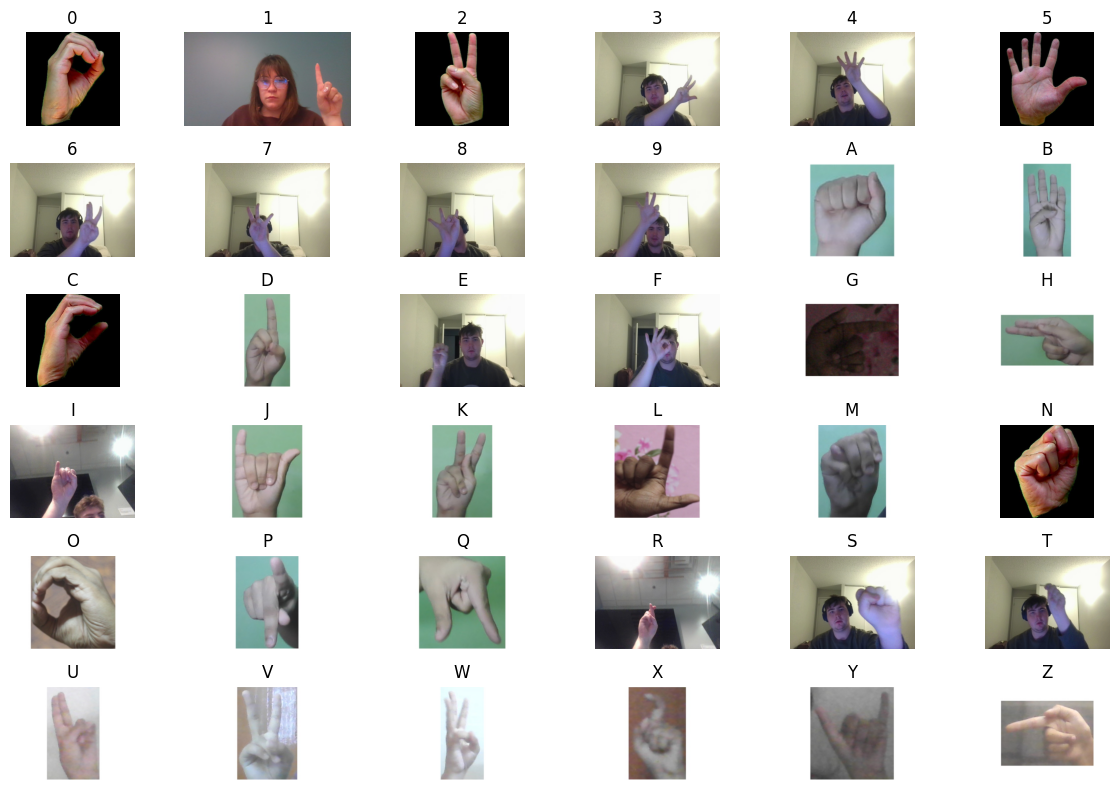

Found 43724 files belonging to 36 classes.
Using 34980 files for training.
Found 43724 files belonging to 36 classes.
Using 8744 files for validation.
Images shape: (64, 128, 128, 3)
Label shape: (64, 36)


In [10]:

# =========================
# Preview one random image per class
# =========================
train_path = output_path + "/train"
labels = sorted([d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))])
num_classes = len(labels)
print(f"{num_classes} classes for training.")

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()


# =========================
# Build train / validation datasets
# =========================
img_size = (128, 128)
batch_size = 64
seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)


# Save class names now, before map() removes that attribute
class_names = train_ds.class_names


# =========================
# Data augmentation
# =========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(10 / 180),
    tf.keras.layers.RandomZoom(height_factor=0.10, width_factor=0.10),
    tf.keras.layers.RandomTranslation(height_factor=0.10, width_factor=0.10),
    tf.keras.layers.RandomContrast(0.15),
], name="asl_augmentation")


# =========================
# Extra color / lighting changes
# =========================
def add_color_jitter(x, y):
    x = tf.cast(x, tf.float32)
    x = tf.image.random_brightness(x, max_delta=0.15 * 255.0)
    x = tf.image.random_hue(x, max_delta=0.03)
    x = tf.image.random_saturation(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, 0.0, 255.0)
    return x, y


# =========================
# Normalization
# =========================
def normalize(x, y):
    x = tf.cast(x, tf.float32)
    x = x / 127.5 - 1.0
    return x, y


# =========================
# Apply pipeline
# train: color jitter -> geometric aug -> normalize
# val: normalize only
# =========================
train_ds = train_ds.map(add_color_jitter, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
train_ds = train_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)

val_ds = val_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)


# =========================
# Format labels for early-exit model
# =========================
train_ds = train_ds.map(lambda x, y: (x, (y, y, y)), num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(lambda x, y: (x, (y, y, y)), num_parallel_calls=tf.data.AUTOTUNE)


# =========================
# Prefetch
# =========================
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)


# =========================
# Optional: inspect one batch
# =========================
for images, labels_triplet in val_ds.take(1):
    print("Images shape:", images.shape)
    print("Label shape:", labels_triplet[0].shape)
    break

load the base of MobileNetV2

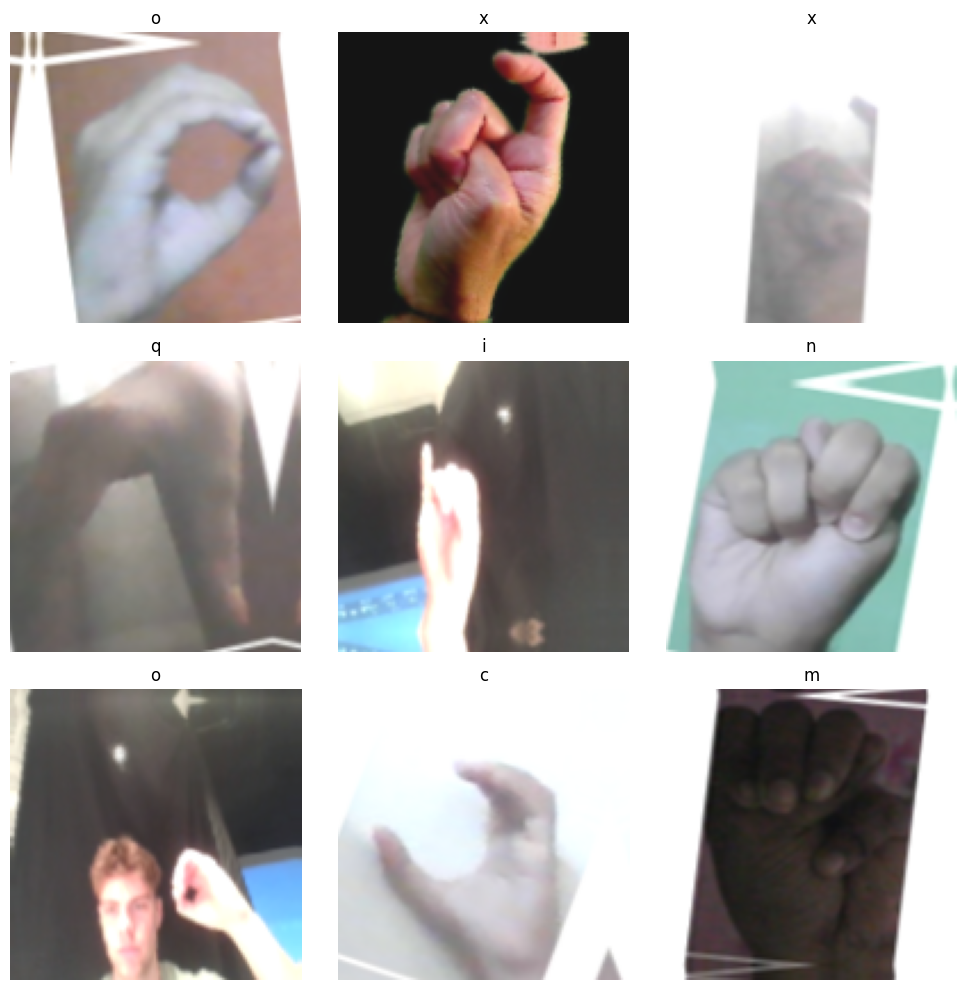

In [11]:
class_names = train_ds.class_names if hasattr(train_ds, "class_names") else labels

plt.figure(figsize=(10, 10))

for images, labels_triplet in train_ds.take(1):
    labels_one_hot = labels_triplet[0]  # all three are the same

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        # convert back from [-1, 1] → [0, 1] for display
        img = (images[i] + 1.0) / 2.0
        img = tf.clip_by_value(img, 0, 1)

        plt.imshow(img.numpy())

        label_index = tf.argmax(labels_one_hot[i]).numpy()
        plt.title(class_names[label_index])

        plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
BaseModel = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Find what layers we should exit from:

In [13]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer_1
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

The expabded relu is where we want to make the early exits, before it is projected

In [14]:
#Exit1 = BaseModel.get_layer("block_3_expand_relu").output
#Exit2 = BaseModel.get_layer("block_12_expand_relu").output

#def ExitHead(x, NumClasses):
#  x = layers.GlobalAveragePooling2D()(x)
#  x = layers.Dense(128, activation='relu')(x)
#  return layers.Dense(NumClasses, activation='softmax')(x)

#Exit1Output = ExitHead(Exit1, 10)
#Exit2Output = ExitHead(Exit2, 10)


#x = BaseModel.output
#x = layers.GlobalAveragePooling2D()(x)
#FinalOutput = layers.Dense(10, activation='softmax')(x)

#NewModel = Model(inputs=BaseModel.input,
#                 outputs=[Exit1Output, Exit2Output, FinalOutput])

In [15]:
# ### GET TRAINING DATA ###


# num_classes = len(labels)
# print(f"{num_classes} classes for training.")

# # redefine train_ds and test_ds using
# # Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     output_path + "/train",
#     image_size=(224, 224),
#     batch_size=64,
#     label_mode='categorical' # Ensures labels are one-hot encoded
# )

# test_ds = tf.keras.utils.image_dataset_from_directory(
#     output_path + "/test",
#     image_size=(224, 224),
#     batch_size=64,
#     label_mode='categorical' # Ensures labels are one-hot encoded
# )


# train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
# test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

# for images, labels_one_hot in test_ds.take(1):
#     break

In [16]:
# ### TRAIN THE MODEL ###


# # Redefine the ExitHead function and the model with the correct number of classes
# Exit1 = BaseModel.get_layer("block_7_expand_relu").output
# Exit2 = BaseModel.get_layer("block_12_expand_relu").output

# def ExitHead(x, num_classes_arg):
#   x = tf.keras.layers.Conv2D(128, (1,1), padding='same', activation='relu')(x)
#   x = tf.keras.layers.BatchNormalization()(x)
#   x = tf.keras.layers.GlobalAveragePooling2D()(x)
#   x = tf.keras.layers.Dense(128, activation='relu')(x)
#   x = tf.keras.layers.Dropout(0.5)(x)
#   return tf.keras.layers.Dense(num_classes_arg, activation='softmax')(x)

# Exit1Output = ExitHead(Exit1, num_classes)
# Exit2Output = ExitHead(Exit2, num_classes)

# x = BaseModel.output
# x = tf.keras.layers.Conv2D(128, (1,1), padding='same', activation='relu')(x)
# x = tf.keras.layers.BatchNormalization()(x)
# x = tf.keras.layers.GlobalAveragePooling2D()(x)
# x = tf.keras.layers.Dense(128, activation='relu')(x)
# x = tf.keras.layers.Dropout(0.5)(x)
# FinalOutput = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

# NewModel = tf.keras.Model(inputs=BaseModel.input,
#                  outputs=[Exit1Output, Exit2Output, FinalOutput])


# # Compile the model
# NewModel.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=['categorical_crossentropy'] * 3,
#     loss_weights = [0.5, 0.5, 1.0],
#     metrics=['accuracy'] * 3) # Fixed: metrics should be a list of 3 for 3 outputs

# # Fit the model
# print("\nStarting model training...")
# NewModel.fit(
#     train_ds,
#     validation_data = test_ds,
#     epochs = 8,
# )

In [17]:
# NewModel.save("/content/drive/MyDrive/Colab Notebooks/ENDG_511/models/model_12.h5")

In [18]:
#run if you want to load model
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/models/model_13.keras")

In [19]:
#run if you want to use newely trained model
#LoadedModel = NewModel

In [20]:
# ### PRUNING STUFF ###
# def manual_prune_model(model, sparsity=0.5, start_layer=None):
#   model_copy = tf.keras.models.clone_model(model)
#   model_copy.set_weights(model.get_weights())

#   for layer in model_copy.layers[start_layer * 8:]:
#       if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
#           weights = layer.get_weights()
#           if not weights:
#               continue

#           w = weights[0]
#           threshold = np.percentile(np.abs(w), sparsity * 100)
#           weights[0] = np.where(np.abs(w) < threshold, 0, w)
#           layer.set_weights(weights)
#   return model_copy

# pruned_model_1 = manual_prune_model(LoadedModel, sparsity=0.1, start_layer=7)
# pruned_model_2 = manual_prune_model(LoadedModel, sparsity=0.2, start_layer=7)
# pruned_model_3 = manual_prune_model(LoadedModel, sparsity=0.3, start_layer=7)
# pruned_model_4 = manual_prune_model(LoadedModel, sparsity=0.4, start_layer=7)

# pruned_models = [pruned_model_1, pruned_model_2, pruned_model_3, pruned_model_4]

# pruned_model_1.save("/content/drive/MyDrive/ENDG511/pruned_models/pruned_model_13.h5")


In [21]:
# ### VALIDATE PRUNING ###
# def print_model_weights_sparsity(model):

#     for layer in model.layers[:-1]:
#         if isinstance(layer, tf.keras.layers.Wrapper):
#             weights = layer.trainable_weights
#         else:
#             weights = layer.weights
#         for weight in weights:
#             if "kernel" not in weight.name or "centroid" in weight.name:
#                 continue
#             weight_size = weight.numpy().size
#             zero_num = np.count_nonzero(weight == 0)
#             print(
#                 f"{weight.name}: {zero_num/weight_size:.2%} sparsity ",
#                 f"({zero_num}/{weight_size})",
#             )
# for pruned_model in pruned_models:
#   print_model_weights_sparsity(pruned_model)

kernel: 0.00% sparsity  (0/432)
kernel: 0.00% sparsity  (0/144)
kernel: 0.00% sparsity  (0/128)
kernel: 0.00% sparsity  (0/384)
kernel: 0.00% sparsity  (0/432)
kernel: 0.00% sparsity  (0/768)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/864)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/864)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/864)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/864)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/1536)
kernel: 0.00% sparsity  (0/864)
kernel: 10.03% sparsity  (308/3072)
kernel: 10.01% sparsity  (615/6144)
kernel: 0.00% sparsity  (0/1728)
kernel: 10.01% sparsity  (615/6144)
kernel: 10.01% sparsity  (615/6144)
kernel: 0.00% sparsity  (0/1728)
kernel: 10.01% sparsity  (615/6144)
kernel: 10.01% sparsity  (615/6144)
kernel: 0.00% sparsity  (0/1728)
kernel: 10.01% sparsity  (615/6144)


In [22]:
### FUNCS FOR FOR LOOP ###
import tempfile

def get_model_size(model):
  tmp_file = tempfile.NamedTemporaryFile(suffix=".keras", delete=False)
  model.save(tmp_file.name)

  size = os.path.getsize(tmp_file.name)
  return size / (1024**2)  # MB

def measure_inference_time(model, dataset, num_batches=50):
    times = []

    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time = (end - start) / x.shape[0]  # per image
        times.append(batch_time)

    return np.mean(times) * 1000  # ms/image

In [23]:
test_path = output_path + "/test"

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

def normalize(x, y):
    x = tf.cast(x, tf.float32)
    x = x / 127.5 - 1.0
    return x, y

test_ds = test_ds.map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

Found 10932 files belonging to 36 classes.


In [24]:
# pruning_configs = [
#     {"model_id": 1, "sparsity": 0.1, "start_layer": 7, "model": pruned_model_1},
#     {"model_id": 2, "sparsity": 0.2, "start_layer": 7, "model": pruned_model_2},
#     {"model_id": 3, "sparsity": 0.3, "start_layer": 7, "model": pruned_model_3},
#     {"model_id": 4, "sparsity": 0.4, "start_layer": 7, "model": pruned_model_4},
# ]

# all_results = []

# for cfg in pruning_configs:
#     CurrentModel = cfg["model"]

#     CurrentModel.compile(
#         optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#         loss=['categorical_crossentropy'] * 3,
#         loss_weights=[0.5, 0.5, 1.0],
#         metrics=[['accuracy'], ['accuracy'], ['accuracy']]
#     )

#     results = CurrentModel.evaluate(test_ds, verbose=0, return_dict=True)

#     all_true = []
#     for _, labels_triplet in test_ds:
#         all_true.append(tf.argmax(labels_triplet[2], axis=1).numpy())
#     all_true = np.concatenate(all_true, axis=0)

#     predictions = CurrentModel.predict(test_ds, verbose=0)

#     exit1_acc = np.mean(np.argmax(predictions[0], axis=1) == all_true)
#     exit2_acc = np.mean(np.argmax(predictions[1], axis=1) == all_true)
#     final_acc = np.mean(np.argmax(predictions[2], axis=1) == all_true)

#     FinalModel = tf.keras.Model(inputs=CurrentModel.input, outputs=CurrentModel.outputs[-1])

#     row = {
#         "model_id": cfg["model_id"],
#         "sparsity": cfg["sparsity"],
#         "start_layer": cfg["start_layer"],
#         "total_loss": results["loss"],
#         "exit1_loss": results.get("dense_1_loss", np.nan),
#         "exit2_loss": results.get("dense_3_loss", np.nan),
#         "final_loss": results.get("dense_5_loss", np.nan),
#         "exit1_acc": exit1_acc,
#         "exit2_acc": exit2_acc,
#         "final_acc": final_acc,
#         "full_model_size_MB": get_model_size(CurrentModel),
#         "final_model_size_MB": get_model_size(FinalModel),
#         "inference_time_s": measure_inference_time(FinalModel, test_ds)
#     }

#     all_results.append(row)

# df = pd.DataFrame(all_results)
# df.to_csv("/content/drive/MyDrive/ENDG511/pruned_model_results_13.csv", index=False)

# print(df)

KeyboardInterrupt: 

In [27]:


# =========================
# LOAD OR START FROM MODEL
# =========================
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/models/model_13.keras")

# =========================
# MANUAL PRUNING
# =========================
def manual_prune_model(model, sparsity=0.3, start_index=0):
    model_copy = tf.keras.models.clone_model(model)
    model_copy.set_weights(model.get_weights())

    for i, layer in enumerate(model_copy.layers[start_index:], start=start_index):
        if isinstance(layer, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            weights = layer.get_weights()
            if not weights:
                continue

            w = weights[0]
            threshold = np.percentile(np.abs(w), sparsity * 100)
            w_pruned = np.where(np.abs(w) < threshold, 0, w)

            new_weights = [w_pruned]
            if len(weights) > 1:
                new_weights.append(weights[1])   # keep bias

            layer.set_weights(new_weights)

            zero_frac = np.mean(w_pruned == 0)
            print(f"Layer {i:3d} {layer.name:25s} sparsity={zero_frac:.3f}")

    return model_copy

pruned_model = manual_prune_model(LoadedModel, sparsity=0.3, start_index=56)

# =========================
# OPTIONAL: FREEZE EARLY LAYERS
# fine-tune only later layers
# =========================
for layer in pruned_model.layers[:56]:
    layer.trainable = False

for layer in pruned_model.layers[56:]:
    layer.trainable = True

# =========================
# RECOMPILE BEFORE FINETUNING
# use low LR so you recover accuracy without wrecking weights
# =========================
pruned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=['categorical_crossentropy'] * 3,
    loss_weights=[0.5, 0.5, 1.0],
    metrics=[['accuracy'], ['accuracy'], ['accuracy']]
)

# =========================
# CALLBACKS
# =========================
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "/content/drive/MyDrive/ENDG511/pruned_models/best_pruned_finetuned.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

# =========================
# FINETUNE
# train_ds and val_ds must already be mapped as (x, (y, y, y))
# =========================
history = pruned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    callbacks=callbacks,
    verbose=1
)

# =========================
# EVALUATE
# =========================
results = pruned_model.evaluate(test_ds, verbose=1, return_dict=True)
print(results)

# =========================
# SAVE
# =========================
pruned_model.save("/content/drive/MyDrive/ENDG511/pruned_models/pruned_model_13_finetuned.keras")

Layer  61 block_6_project           sparsity=0.300
Layer  63 block_7_expand            sparsity=0.300
Layer  69 block_7_project           sparsity=0.300
Layer  72 block_8_expand            sparsity=0.300
Layer  78 block_8_project           sparsity=0.300
Layer  81 block_9_expand            sparsity=0.300
Layer  87 block_9_project           sparsity=0.300
Layer  90 block_10_expand           sparsity=0.300
Layer  96 block_10_project          sparsity=0.300
Layer  98 block_11_expand           sparsity=0.300
Layer 104 block_11_project          sparsity=0.300
Layer 107 block_12_expand           sparsity=0.300
Layer 113 block_12_project          sparsity=0.300
Layer 116 block_13_expand           sparsity=0.300
Layer 123 block_13_project          sparsity=0.300
Layer 125 block_14_expand           sparsity=0.300
Layer 131 block_14_project          sparsity=0.300
Layer 134 block_15_expand           sparsity=0.300
Layer 140 block_15_project          sparsity=0.300
Layer 143 block_16_expand      

In [28]:
pruned_model.save("/content/drive/MyDrive/ENDG511/pruned_models/pruned_0.3_model_13_finetuned.keras")

In [29]:
pruned_model_20 = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/pruned_models/pruned_0.2_model_13_finetuned.keras")
pruned_model_30 = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/pruned_models/pruned_0.3_model_13_finetuned.keras")
pruned_model_40 = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/pruned_models/pruned_0.4_model_13_finetuned.keras")
pruned_model_50 = tf.keras.models.load_model("/content/drive/MyDrive/ENDG511/pruned_models/pruned_0.5_model_13_finetuned.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 248 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [30]:
import os
import time
import tempfile
import numpy as np
import pandas as pd
import tensorflow as tf

# --------------------------------------------------
# Save-size helper
# --------------------------------------------------
def get_model_size_mb(model, suffix=".keras"):
    tmp_file = tempfile.NamedTemporaryFile(suffix=suffix, delete=False)
    tmp_path = tmp_file.name
    tmp_file.close()

    model.save(tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 ** 2)

    # clean up temp file
    try:
        os.remove(tmp_path)
    except:
        pass

    return size_mb

# --------------------------------------------------
# Inference-time helper
# returns ms/image
# --------------------------------------------------
def measure_inference_time_ms(model, dataset, num_batches=50, warmup_batches=3):
    times = []

    # warmup
    for i, (x, _) in enumerate(dataset.take(warmup_batches)):
        _ = model(x, training=False)

    # actual timing
    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time_per_image = (end - start) / x.shape[0]
        times.append(batch_time_per_image)

    return np.mean(times) * 1000.0  # ms/image

# --------------------------------------------------
# Main evaluator for a fine-tuned 3-output model
# test_ds must be mapped as: (x, (y, y, y))
# --------------------------------------------------
def evaluate_finetuned_model(
    model,
    test_ds,
    model_name="model",
    learning_rate=1e-5,
    num_timing_batches=50
):
    # compile so evaluate() works consistently on your 3-output model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=['categorical_crossentropy'] * 3,
        loss_weights=[0.5, 0.5, 1.0],
        metrics=[['accuracy'], ['accuracy'], ['accuracy']]
    )

    # -----------------------------
    # Keras evaluate metrics
    # -----------------------------
    results = model.evaluate(test_ds, verbose=0, return_dict=True)

    # -----------------------------
    # Gather all true labels
    # -----------------------------
    all_true = []
    for _, labels_triplet in test_ds:
        all_true.append(tf.argmax(labels_triplet[2], axis=1).numpy())
    all_true = np.concatenate(all_true, axis=0)

    # -----------------------------
    # Predict all exits
    # predictions[0] = exit1
    # predictions[1] = exit2
    # predictions[2] = final
    # -----------------------------
    predictions = model.predict(test_ds, verbose=0)

    exit1_pred = np.argmax(predictions[0], axis=1)
    exit2_pred = np.argmax(predictions[1], axis=1)
    final_pred = np.argmax(predictions[2], axis=1)

    exit1_acc = np.mean(exit1_pred == all_true)
    exit2_acc = np.mean(exit2_pred == all_true)
    final_acc = np.mean(final_pred == all_true)

    # -----------------------------
    # Build single-output final model
    # -----------------------------
    final_model = tf.keras.Model(
        inputs=model.input,
        outputs=model.outputs[-1]
    )

    # -----------------------------
    # Measure sizes
    # -----------------------------
    full_model_size_mb = get_model_size_mb(model, suffix=".keras")
    final_model_size_mb = get_model_size_mb(final_model, suffix=".keras")

    # -----------------------------
    # Measure inference times
    # full model returns all exits
    # final model returns final exit only
    # -----------------------------
    full_model_inference_ms = measure_inference_time_ms(
        model, test_ds, num_batches=num_timing_batches
    )
    final_model_inference_ms = measure_inference_time_ms(
        final_model, test_ds, num_batches=num_timing_batches
    )

    # -----------------------------
    # Pack results
    # -----------------------------
    row = {
        "model_name": model_name,

        "total_loss": results.get("loss", np.nan),

        "exit1_loss": results.get("dense_1_loss", np.nan),
        "exit2_loss": results.get("dense_3_loss", np.nan),
        "final_loss": results.get("dense_5_loss", np.nan),

        "exit1_acc": exit1_acc,
        "exit2_acc": exit2_acc,
        "final_acc": final_acc,

        "full_model_size_MB": full_model_size_mb,
        "final_model_size_MB": final_model_size_mb,

        "full_model_inference_ms_per_image": full_model_inference_ms,
        "final_model_inference_ms_per_image": final_model_inference_ms
    }

    return pd.DataFrame([row])

In [32]:
df_ft_20 = evaluate_finetuned_model(
    pruned_model_20,
    test_ds,
    model_name="ft_pruned_0.2",
    learning_rate=1e-5,
    num_timing_batches=50
)

df_ft_30 = evaluate_finetuned_model(
    pruned_model_30,
    test_ds,
    model_name="ft_pruned_0.3",
    learning_rate=1e-5,
    num_timing_batches=50
)

df_ft_40 = evaluate_finetuned_model(
    pruned_model_40,
    test_ds,
    model_name="ft_pruned_0.4",
    learning_rate=1e-5,
    num_timing_batches=50
)

df_ft_50 = evaluate_finetuned_model(
    pruned_model_50,
    test_ds,
    model_name="ft_pruned_0.5",
    learning_rate=1e-5,
    num_timing_batches=50
)

all_ft_results = pd.concat([df_ft_20, df_ft_30, df_ft_40, df_ft_50], ignore_index=True)

all_ft_results.to_csv("/content/drive/MyDrive/ENDG511/finetuned_pruned_model_results.csv", index=False)


In [ ]:
# ### ONLY RUN IF YOU WANT TO EVALUATE PRUNED MODEL ###
# LoadedModel = pruned_model

# LoadedModel.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#     loss=['categorical_crossentropy'] * 3,
#     loss_weights=[0.5, 0.5, 1.0],
#     metrics=['accuracy'] * 3
# )

In [ ]:
# results = LoadedModel.evaluate(test_ds, verbose=0)
# metric_names = LoadedModel.metrics_names

# # zip ensures matching length
# df = pd.DataFrame(list(zip(metric_names, results)),
#                   columns=["Metric", "Value"])

# print(df.to_string(index=False))

In [ ]:
# ### USE THE TRAINED MODEL TO MAKE PREDICTIONS FOR VALIDATION ###

# predictions = LoadedModel.predict(images)
# true_labels = tf.argmax(labels_triplet[2], axis=-1).numpy()
# exit_names = ["Exit 1 (early exit)", "Exit 2 (intermediate exit)", "Final Output"]

# for i, pred in enumerate(predictions):
#     y_pred = np.argmax(pred, axis=1)
#     accuracy = np.mean(y_pred == true_labels)
#     print(f"Overall accuracy for {exit_names[i]}: {accuracy*100:.2f}%")

In [ ]:
### CODE FOR MEASURING MODEL SIZE IN MB ###
import tempfile

def get_model_size(model):
    tmp_file = tempfile.NamedTemporaryFile(suffix=".keras", delete=False)
    model.save(tmp_file.name)

    size = os.path.getsize(tmp_file.name)
    return size / (1024**2)  # MB


FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])


print("Full model size (MB):", get_model_size(NewModel))
print("Final model size (MB):", get_model_size(FinalModel))

In [ ]:
### CODE FOR MEASURING INFERENCE TIME ###

def measure_inference_time(model, dataset, num_batches=50):
    times = []

    for i, (x, _) in enumerate(dataset.take(num_batches)):
        start = time.time()
        _ = model(x, training=False)
        end = time.time()

        batch_time = (end - start) / x.shape[0]  # per image
        times.append(batch_time)

    return np.mean(times) * 1000  # ms/image

FinalModel = Model(inputs=NewModel.input, outputs=NewModel.outputs[-1])
print("Inference time:", measure_inference_time(FinalModel, test_ds))


In [ ]:
### SHOWS INPUTS, PREDICTIONS AND THE RESPONSE ###

true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(15, 10))
  for i in range(min(len(images), 9)):
      plt.subplot(3, 3, i + 1)
      plt.imshow(images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"True: {true_class_name.upper()}\nPred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [ ]:
### EVALUATES EACH EARLY EXIT ###

y_pred0_list = []
y_pred1_list = []
y_pred2_list = []
y_trues_list = []
j=0

for x_batch, y_batch in test_ds:
  j+=1
  preds = LoadedModel.predict(x_batch, verbose=0)
  preds0_classes = np.argmax(preds[0], axis=1)
  preds1_classes = np.argmax(preds[1], axis=1)
  preds2_classes = np.argmax(preds[2], axis=1)
  y_trues_list.extend(tf.argmax(y_batch[0], axis=1).numpy())
  y_pred0_list.extend(preds0_classes)
  y_pred1_list.extend(preds1_classes)
  y_pred2_list.extend(preds2_classes)
  if j==10: #change depending on how many points in matrix you want
    break

y_preds = [np.array(y_pred0_list), np.array(y_pred1_list), np.array(y_pred2_list)]
y_true = np.array(y_trues_list)



In [ ]:
### SHOWS THE CONFUSION MATRIX FOR THE EXITS ###
exits = ["Exit 1", "Exit 2", "Exit Final"]
i = 0
for y_pred in y_preds:
  cm = confusion_matrix(y_true, y_pred)
  class_labels = sorted(os.listdir(output_path + "/train"))

  plt.figure(figsize=(12,10))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=class_labels,
              yticklabels=class_labels)
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.title(f"Confusion Matrix - {exits[i]}")
  i +=1
  plt.show()